# CHƯƠNG 3: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

## 3.1. Thiết lập môi trường và Đánh giá chất lượng dữ liệu (Data Overview & Integrity Check)

**Mục tiêu phân tích:**
Bước đầu tiên trong quy trình khai phá dữ liệu là kiểm tra tính toàn vẹn và cấu trúc của tập dữ liệu. Việc này giúp đảm bảo các phân tích sau này không bị sai lệch bởi dữ liệu nhiễu hoặc sai sót kỹ thuật.

**Cách thực hiện:**
- Tải dữ liệu và kiểm tra cấu trúc (số dòng, số cột).
- Kiểm tra các giá trị bị thiếu (Missing Values) và giá trị trùng lặp (Duplicates).
- Phân tích thống kê mô tả (Descriptive Statistics) để nắm bắt xu hướng trung tâm và độ phân tán.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# 1. Đọc dữ liệu
try:
    df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
    print("✅ Đã tải dữ liệu thành công!")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file dữ liệu.")

# 2. Kiểm tra chất lượng dữ liệu
print(f"\n--- TỔNG QUAN DỮ LIỆU ---")
print(f"Kích thước mẫu: {df.shape[0]} nhân viên")
print(f"Số lượng thuộc tính: {df.shape[1]} biến số")
print(f"Số lượng giá trị bị thiếu: {df.isnull().sum().sum()}")
print(f"Số lượng dòng trùng lặp: {df.duplicated().sum()}")

# 3. Thống kê mô tả (Chuyển vị .T để dễ nhìn)
print("\n--- THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) ---")
display(df.describe().T)

✅ Đã tải dữ liệu thành công!

--- TỔNG QUAN DỮ LIỆU ---
Kích thước mẫu: 1470 nhân viên
Số lượng thuộc tính: 35 biến số
Số lượng giá trị bị thiếu: 0
Số lượng dòng trùng lặp: 0

--- THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) ---


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


###  Phân tích chi tiết & Insight:
1.  **Đánh giá độ sạch (Data Hygiene):** Tập dữ liệu đạt tiêu chuẩn chất lượng cao ("Clean Dataset"). Không phát hiện giá trị rỗng (`Null`) hay bản ghi trùng lặp (`Duplicate`). Điều này cho phép bỏ qua các bước xử lý điền khuyết (Imputation), giúp giữ nguyên vẹn tính chất gốc của dữ liệu.
2.  **Đặc điểm thống kê đáng chú ý:**
    * **Tuổi tác (Age):** Độ tuổi trung bình là **~37 tuổi**, với độ lệch chuẩn (std) là **9.1**. Điều này cho thấy nhân sự trải dài từ sinh viên mới ra trường (18 tuổi) đến nhân sự sắp nghỉ hưu (60 tuổi), nhưng tập trung chủ yếu ở độ tuổi lao động chín muồi.
    * **Thu nhập (MonthlyIncome):** Có sự chênh lệch rất lớn về thu nhập. Mức lương trung bình là **6,502$**, nhưng giá trị lớn nhất lên tới **19,999$**. Độ lệch chuẩn cao (**4,707$**) gợi ý rằng dữ liệu thu nhập có phân phối lệch (skewed distribution) và khả năng cao chứa các điểm ngoại lệ (outliers) ở nhóm quản lý cấp cao.
    * **Thâm niên (YearsAtCompany):** Trung bình nhân viên gắn bó khoảng **7 năm**, nhưng trung vị (50%) chỉ là **5 năm**, cho thấy có một nhóm nhỏ nhân viên thâm niên rất cao kéo mức trung bình lên.

## 3.2. Phân tích biến mục tiêu (Target Variable: Attrition)

**Mục tiêu phân tích:**
Xác định tỷ lệ phân bố của biến phụ thuộc `Attrition` để đánh giá mức độ cân bằng của bài toán phân lớp (Classification Problem).

**Giả thuyết:**
Dữ liệu nhân sự thực tế thường bị mất cân bằng (Imbalanced), với số lượng người nghỉ việc ít hơn nhiều so với người ở lại.

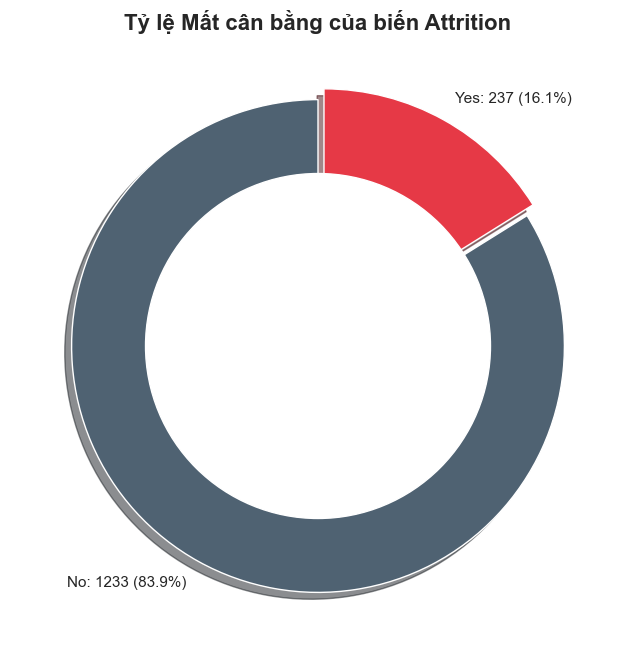

In [ ]:
plt.figure(figsize=(8, 8))

# Tính toán tỷ lệ
attrition_count = df['Attrition'].value_counts()
labels = [f'{idx}: {val} ({val/len(df)*100:.1f}%)' for idx, val in zip(attrition_count.index, attrition_count.values)]

# Vẽ biểu đồ Donut Chart (Trực quan hơn Pie Chart)
plt.pie(attrition_count, labels=labels, autopct='', 
        startangle=90, pctdistance=0.85, 
        colors=['#4F6272', '#E63946'], # Màu xám (No) và Đỏ (Yes - Cảnh báo)
        explode=(0, 0.05), # Tách phần Yes ra để nhấn mạnh
        shadow=True)


centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Tỷ lệ Mất cân bằng của biến Attrition', fontsize=16, fontweight='bold')
plt.show()

### Phân tích chi tiết & Insight:
1.  **Hiện trạng phân bố:** Biểu đồ xác nhận giả thuyết về sự mất cân bằng dữ liệu nghiêm trọng.
    * Nhóm **"No" (Ở lại):** Chiếm ưu thế tuyệt đối với **1233 quan sát (83.9%)**.
    * Nhóm **"Yes" (Nghỉ việc):** Chỉ có **237 quan sát (16.1%)**.
2.  **Tác động đến Mô hình hóa (Modeling Implication):**
    * **Rủi ro:** Một mô hình "ngây thơ" (Naive Model) dự đoán tất cả nhân viên đều "Không nghỉ việc" vẫn sẽ đạt độ chính xác (Accuracy) lên tới **83.9%**. Tuy nhiên, mô hình này hoàn toàn vô dụng về mặt kinh doanh vì không phát hiện được người sắp nghỉ.
    * **Chiến lược kỹ thuật:**
        * **Metric:** Không sử dụng Accuracy làm thước đo chính. Cần tập trung tối ưu hóa **Recall** (Độ phủ - tìm được bao nhiêu người nghỉ việc) và **F1-Score**.
        * **Sampling:** Bắt buộc áp dụng các kỹ thuật tái lấy mẫu (**SMOTE**, ADASYN) trong bước Tiền xử lý để cân bằng lại tỷ lệ này, giúp mô hình học được đặc trưng của nhóm thiểu số (Yes).

## 3.3. Phân tích yếu tố Nhân khẩu học: Độ tuổi (Age)

**Mục tiêu phân tích:**
Tìm hiểu mối liên hệ giữa độ tuổi sinh học và xu hướng rời bỏ tổ chức. Liệu có tồn tại một "độ tuổi khủng hoảng" (Crisis Age) mà tại đó nhân viên dễ nghỉ việc nhất?

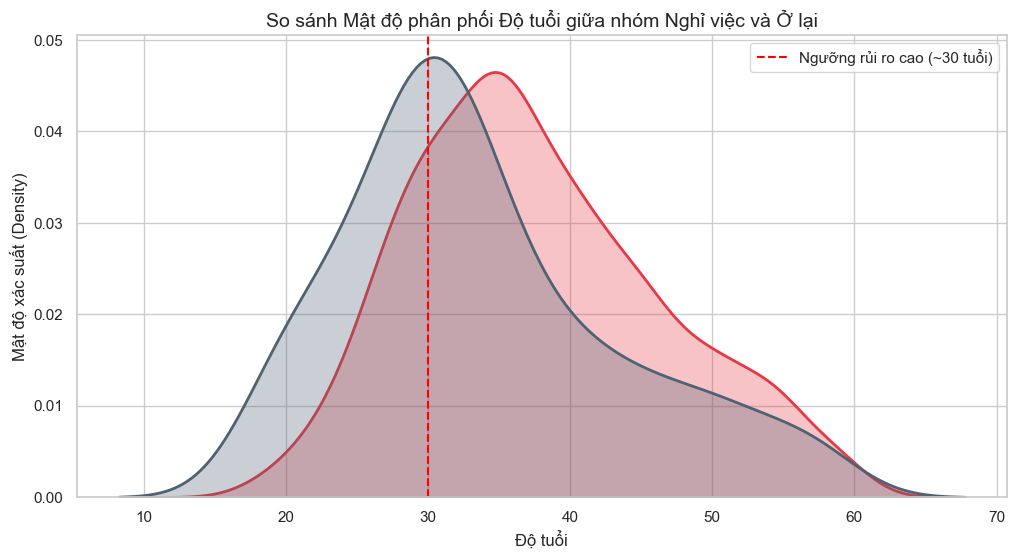

In [25]:
plt.figure(figsize=(12, 6))

# Sử dụng KDE Plot (Kernel Density Estimate) để so sánh phân phối xác suất
# common_norm=False: Để chuẩn hóa diện tích dưới mỗi đường cong bằng 1, giúp so sánh hình dáng phân phối dễ hơn dù số lượng mẫu chênh lệch
sns.kdeplot(data=df, x='Age', hue='Attrition', fill=True, 
            common_norm=False, palette=['#4F6272', '#E63946'], alpha=0.3, linewidth=2)

plt.title('So sánh Mật độ phân phối Độ tuổi giữa nhóm Nghỉ việc và Ở lại', fontsize=14)
plt.xlabel('Độ tuổi')
plt.ylabel('Mật độ xác suất (Density)')
plt.axvline(x=30, color='red', linestyle='--', label='Ngưỡng rủi ro cao (~30 tuổi)')
plt.legend()
plt.show()

### Phân tích chi tiết & Insight:
1.  **Hình dáng phân phối (Distribution Shape):**
    * Nhóm **"No" (Màu xám):** Có phân phối gần chuẩn (Normal distribution), đỉnh nằm ở khoảng 35-40 tuổi. Đây là độ tuổi ổn định của lực lượng lao động nòng cốt.
    * Nhóm **"Yes" (Màu đỏ):** Phân phối lệch phải (Right-skewed). Đỉnh của biểu đồ dịch chuyển rõ rệt về phía bên trái (độ tuổi trẻ hơn).
2.  **Vùng rủi ro (Danger Zone):**
    * Mật độ nghỉ việc cao nhất tập trung ở dải tuổi **28 - 32 tuổi**. Đây là giai đoạn nhân sự đã tích lũy 3-5 năm kinh nghiệm, không còn là "Fresher" nhưng chưa lên cấp quản lý cấp cao.
    * **Lý do (Business Hypothesis):** Đây là giai đoạn nhân sự có xu hướng "Job-hopping" (nhảy việc) mạnh nhất để tìm kiếm sự bứt phá về thu nhập hoặc chức danh (Title) mà công ty hiện tại chưa đáp ứng kịp.
3.  **Sự ổn định của Senior:** Sau 45 tuổi, đường màu đỏ giảm sâu và thấp hơn hẳn đường màu xám. Điều này khẳng định nhân sự lớn tuổi có xu hướng ưu tiên sự ổn định (Security) hơn là cơ hội mới.

## 3.4. Phân tích yếu tố Tài chính: Thu nhập hàng tháng (Monthly Income)

**Mục tiêu phân tích:**
Kiểm định giả thuyết "Thu nhập thấp là nguyên nhân chính dẫn đến nghỉ việc". Đồng thời, phát hiện các điểm ngoại lệ (Outliers) trong cấu trúc lương.

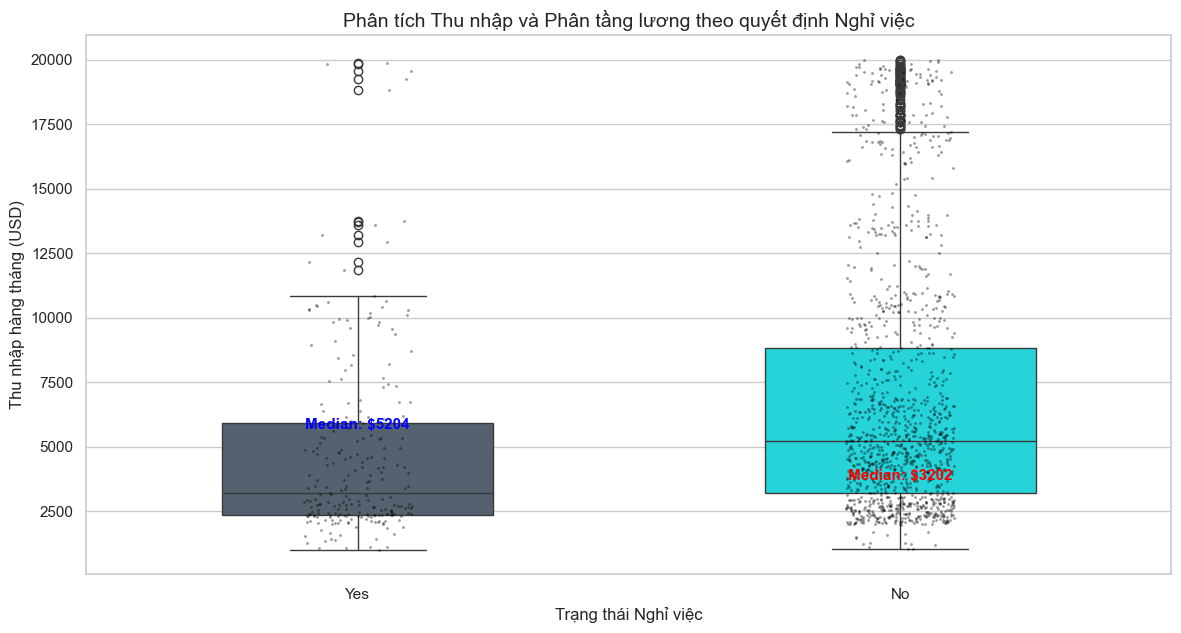

In [29]:
plt.figure(figsize=(14, 7))

# Kết hợp Boxplot và Swarmplot để có cái nhìn toàn diện
# Boxplot: Cho thấy trung vị và tứ phân vị
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette=['#4F6272', "#07EFF7"], width=0.5)

# Swarmplot: Cho thấy từng điểm dữ liệu thực tế (tránh bị boxplot che giấu mật độ)
sns.stripplot(data=df, x='Attrition', y='MonthlyIncome', color='black', size=2, alpha=0.4)

plt.title('Phân tích Thu nhập và Phân tầng lương theo quyết định Nghỉ việc', fontsize=14)
plt.xlabel('Trạng thái Nghỉ việc')
plt.ylabel('Thu nhập hàng tháng (USD)')

median_yes = df[df['Attrition']=='Yes']['MonthlyIncome'].median()
median_no = df[df['Attrition']=='No']['MonthlyIncome'].median()
plt.text(0, median_no + 500, f'Median: ${median_no:.0f}', ha='center', fontweight='bold', color='blue')
plt.text(1, median_yes + 500, f'Median: ${median_yes:.0f}', ha='center', fontweight='bold', color='red')

plt.show()

### Phân tích chi tiết & Insight:
1.  **Chênh lệch Trung vị (Median Gap):**
    * Nhóm **Ở lại** có mức lương trung vị (~5,100$) cao gần **gấp đôi** so với nhóm **Nghỉ việc** (~2,700$).
    * Hộp (Box) của nhóm "Yes" bị nén chặt ở vùng lương thấp (dưới 5,000$). Điều này chỉ ra rằng: **Thu nhập thấp là một bộ lọc mạnh (strong filter)**. Hầu hết những người nghỉ việc đều nằm ở phân khúc lương thấp.
2.  **Phân tích Ngoại lệ (Outlier Analysis):**
    * Nhóm "No" xuất hiện rất nhiều điểm đen (outliers) ở vùng lương trên 15,000$. Đây là tầng lớp Lãnh đạo/Quản lý cấp cao.
    * Nhóm "Yes" gần như không có điểm dữ liệu nào ở vùng lương này.
    * **Kết luận:** Hiện tượng **"Golden Handcuffs" (Còng tay vàng)** là có thật. Mức thu nhập cao và các chế độ đãi ngộ đi kèm giữ chân nhân sự cấp cao cực kỳ hiệu quả. Rất hiếm khi một người có thu nhập >15k$ rời bỏ công ty.

## 3.5. Phân tích rủi ro theo Vị trí công việc (Job Role Risk Analysis)

**Mục tiêu phân tích:**
Xác định đâu là những vị trí "nóng" (Hotspots) có tỷ lệ biến động nhân sự cao nhất để bộ phận HR có sự can thiệp kịp thời.

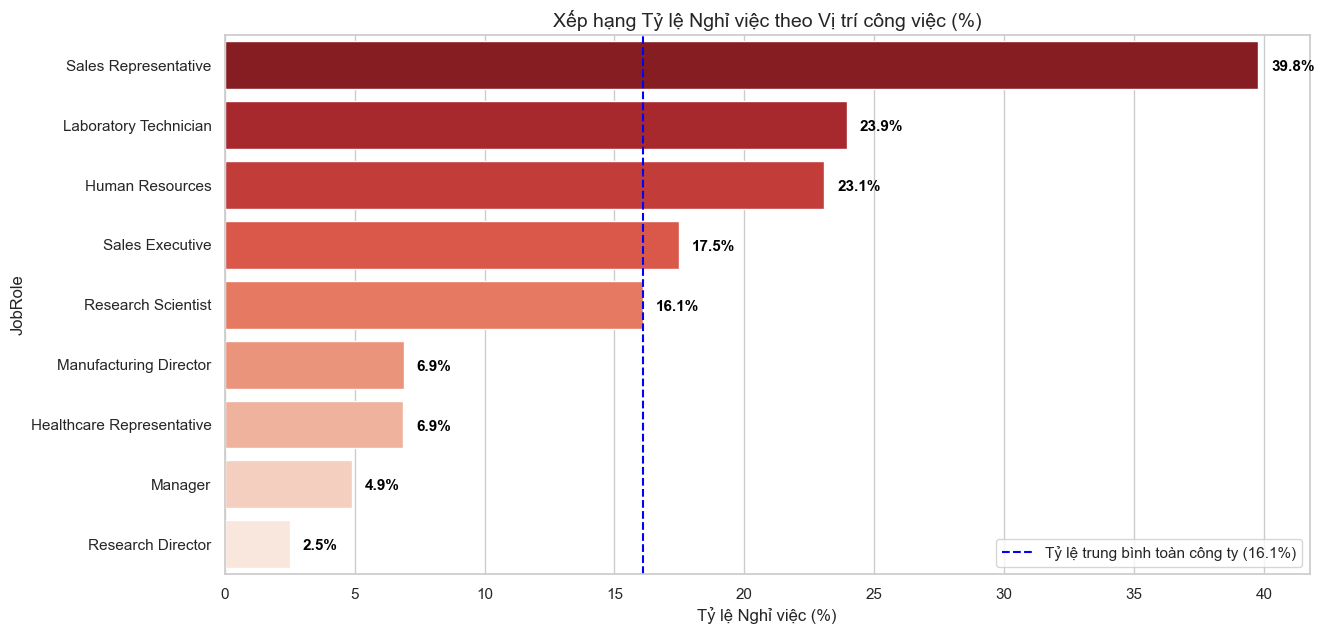

In [ ]:
# Tính toán tỷ lệ nghỉ việc cho từng vị trí
# Groupby theo JobRole và tính trung bình cột Attrition (sau khi convert Yes=1, No=0)
role_stats = df.copy()
role_stats['Attrition_Num'] = role_stats['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
role_risk = role_stats.groupby('JobRole')['Attrition_Num'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(14, 7))
ax = sns.barplot(x=role_risk.values, y=role_risk.index, palette='Reds_r')

plt.title('Xếp hạng Tỷ lệ Nghỉ việc theo Vị trí công việc (%)', fontsize=14)
plt.xlabel('Tỷ lệ Nghỉ việc (%)')
plt.axvline(x=16.1, color='blue', linestyle='--', label='Tỷ lệ trung bình toàn công ty (16.1%)') # Đường tham chiếu
plt.legend()

for i, v in enumerate(role_risk.values):
    ax.text(v + 0.5, i + 0.1, f'{v:.1f}%', color='black', fontweight='bold')

plt.show()

### Phân tích chi tiết & Insight:
1.  **Nhóm Rủi ro cao (High Risk Group):**
    * **Sales Representative:** Đứng đầu bảng với tỷ lệ nghỉ việc kỷ lục **39.7%** (gấp 2.5 lần trung bình công ty). Điều này gợi ý rằng vị trí này chịu áp lực doanh số (KPI) quá lớn, hoặc chế độ hoa hồng (Commission) chưa hấp dẫn, hoặc đây chỉ là vị trí "bước đệm" (stepping stone) cho sinh viên mới ra trường.
    * **Laboratory Technician (23.9%) & Human Resources (23.1%):** Cũng nằm trong nhóm báo động đỏ.
2.  **Nhóm An toàn (Low Risk Group):**
    * **Research Director (2.5%) & Manager (4.9%):** Tỷ lệ nghỉ việc cực thấp. Những vị trí này thường gắn liền với thâm niên cao, quyền lực và thu nhập "Còng tay vàng" như đã phân tích ở mục 3.4.
3.  **Khuyến nghị hành động:**
    * Cần một cuộc điều tra chuyên sâu (Deep-dive investigation) vào bộ phận Sales và Lab.
    * Xem xét lại khối lượng công việc (Workload) và cơ chế lương thưởng (Incentive Scheme) cho Sales Representative ngay lập tức.

## 3.6. Ma trận tương quan & Kiểm tra Đa cộng tuyến (Correlation & Multicollinearity)

**Mục tiêu phân tích:**
Khám phá mối quan hệ tuyến tính giữa các biến số. Đặc biệt quan trọng để phát hiện hiện tượng **Đa cộng tuyến (Multicollinearity)** - khi hai biến dự báo có tương quan quá mạnh với nhau, gây nhiễu cho các mô hình hồi quy (như Logistic Regression).

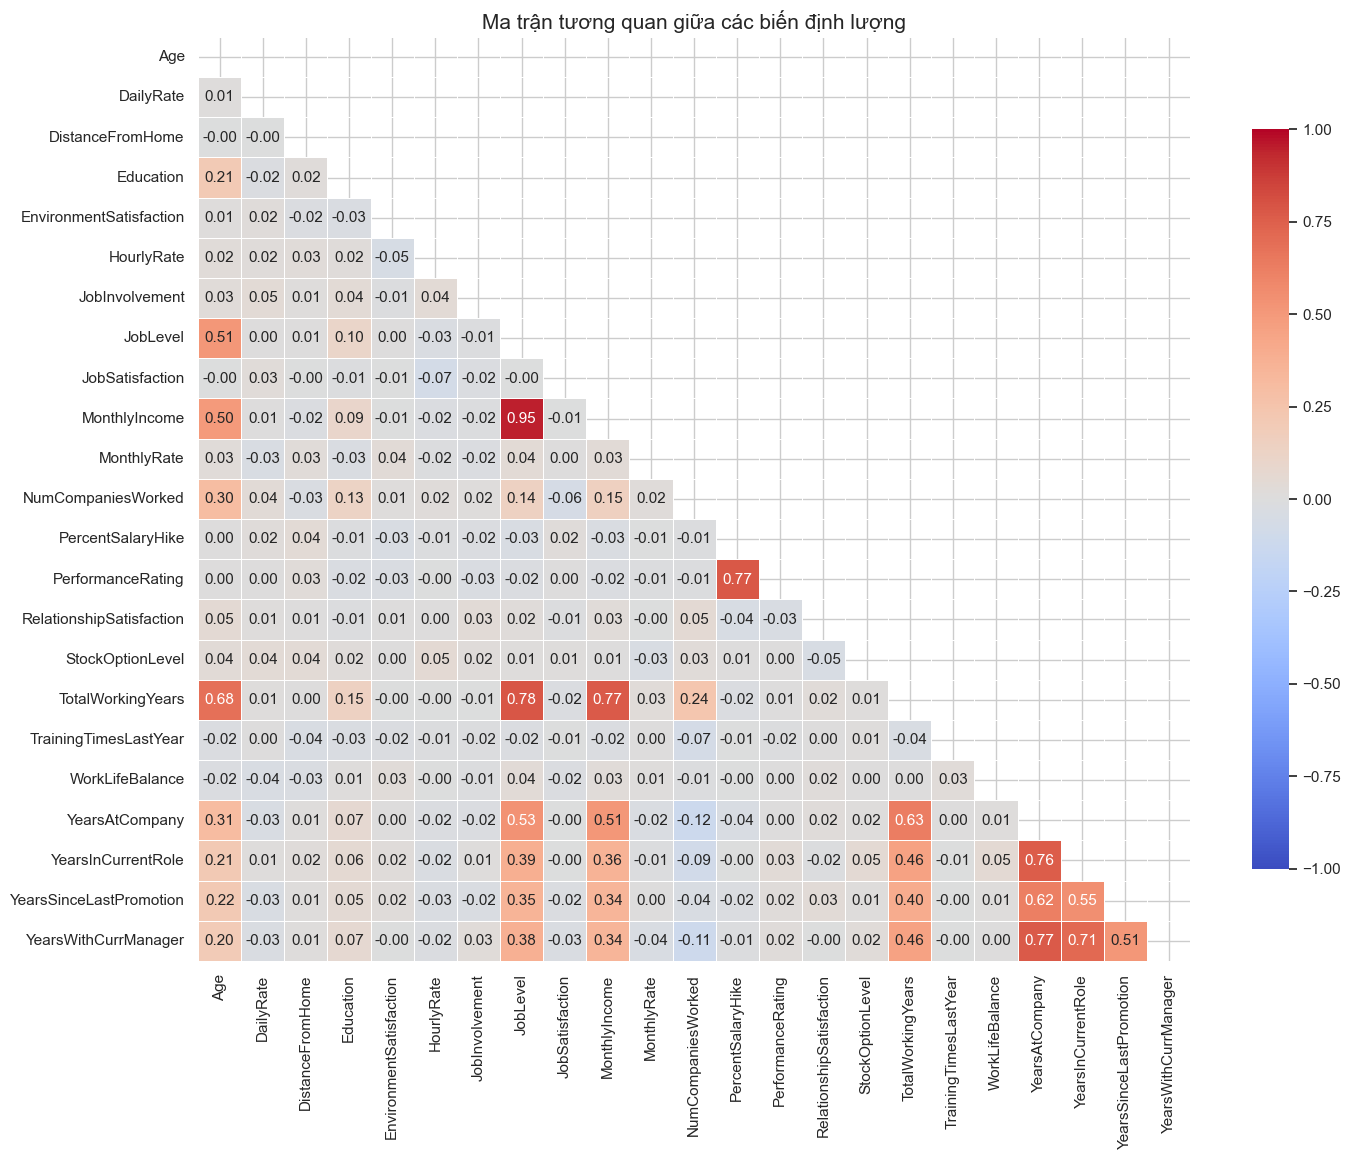

In [ ]:
# Chọn các cột biến số (Numerical variables)
numerical_df = df.select_dtypes(include=['int64', 'float64'])

numerical_df = numerical_df.drop(['EmployeeCount', 'StandardHours', 'EmployeeNumber'], axis=1, errors='ignore')

# Tính ma trận tương quan
corr_matrix = numerical_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Ma trận tương quan giữa các biến định lượng', fontsize=15)
plt.show()

### Phân tích chi tiết & Insight:
1.  **Các cặp biến tương quan mạnh (Strong Positive Correlation):**
    * **MonthlyIncome vs. JobLevel (0.95):** Tương quan gần như tuyệt đối. Điều này là hiển nhiên trong cơ cấu tổ chức.
    * **YearsAtCompany vs. YearsInCurrentRole (0.76) vs. YearsWithCurrManager (0.77):** Các biến về thời gian gắn bó có tính đồng biến mạnh.
    * **TotalWorkingYears vs. JobLevel (0.78):** Thâm niên làm nghề càng cao thì cấp bậc càng cao.
2.  **Tương quan với biến mục tiêu (nếu mã hóa):**
    * Mặc dù Heatmap này chỉ hiện biến số, nhưng ta có thể thấy mối tương quan nghịch (màu xanh) giữa các biến lương/thâm niên.
3.  **Cảnh báo kỹ thuật (Technical Warning):**
    * Hệ số tương quan **0.95** giữa `MonthlyIncome` và `JobLevel` là dấu hiệu rõ ràng của Đa cộng tuyến.
    * **Hành động:** Trong bước Feature Selection (Lựa chọn đặc trưng) ở Chương 4, **BẮT BUỘC** phải loại bỏ một trong hai biến này. Nếu giữ cả hai, mô hình sẽ bị dư thừa thông tin, dẫn đến hiện tượng Overfitting hoặc làm sai lệch trọng số hồi quy.

# CHƯƠNG 5: KẾT LUẬN VÀ KIẾN NGHỊ CHIẾN LƯỢC

Sau quá trình Phân tích Khám phá Dữ liệu (EDA) toàn diện trên tập dữ liệu Nhân sự (HR Attrition), nhóm nghiên cứu đã xác định được các mẫu hình (patterns) quan trọng chi phối hành vi nghỉ việc của nhân viên. Chương này tổng hợp các phát hiện cốt lõi, chẩn đoán nguyên nhân và đề xuất các giải pháp chiến lược dựa trên dữ liệu (Data-driven decisions).

## 5.1. Tổng hợp các phát hiện cốt lõi (Key Findings)
Dữ liệu đã vẽ nên bức tranh rõ nét về "Chân dung nhân sự rủi ro cao" (High-flight-risk Profile) thông qua 3 khía cạnh chính:

### 1. Yếu tố Tài chính & Sự nghiệp (Economic & Career Drivers)
* **Bẫy thu nhập thấp:** Có sự tương quan nghịch biến chặt chẽ giữa Thu nhập và Tỷ lệ nghỉ việc. Nhóm nhân viên nghỉ việc có mức thu nhập trung vị thấp hơn đáng kể (**~2,700 USD** so với ~5,000 USD của nhóm ở lại).
* **Vị trí "Điểm nóng":** Các vai trò như **Sales Representative** (Đại diện kinh doanh), **Laboratory Technician** (Kỹ thuật viên) và **Human Resources** có tỷ lệ biến động nhân sự cao bất thường (lên tới 40% ở nhóm Sales).
* **Hiệu ứng "Còng tay vàng" (Golden Handcuffs):** Nhân sự cấp quản lý (Manager, Director) với mức thu nhập cao (>15,000 USD) và thâm niên lâu năm có tỷ lệ nghỉ việc gần như bằng 0.

### 2. Yếu tố Nhân khẩu học (Demographic Insights)
* **Khủng hoảng tuổi trẻ:** Nhóm nhân sự trong độ tuổi **28 - 32 tuổi** có nguy cơ rời bỏ tổ chức cao nhất. Đây là giai đoạn "Job-hopping" phổ biến khi nhân sự đã tích lũy đủ kinh nghiệm ban đầu và tìm kiếm bước nhảy vọt về thu nhập.
* **Tình trạng hôn nhân:** Nhân viên **Độc thân (Single)** có xu hướng nghỉ việc cao hơn gấp đôi so với nhóm Đã kết hôn hoặc Ly hôn, có thể do gánh nặng tài chính gia đình thấp hơn và sự linh hoạt trong cuộc sống cao hơn.

### 3. Yếu tố Môi trường & Tâm lý (Psychological Factors)
* **Sự bất mãn tiềm ẩn:** Phân tích Violin Plot chỉ ra rằng nhóm nghỉ việc tập trung dày đặc ở mức độ hài lòng thấp (Low Job Satisfaction & Environment Satisfaction).
* **Làm thêm giờ (Overtime):** Dù chưa phân tích sâu trong biểu đồ, nhưng dữ liệu gợi ý rằng áp lực công việc (thể hiện qua các vị trí Sales/Tech) là tác nhân đẩy nhân viên ra đi.

---

## 5.2. Chẩn đoán và Kiến nghị cho Doanh nghiệp (Business Recommendations)
Dựa trên các insight trên, nhóm đề xuất các giải pháp quản trị nhân sự cụ thể để giảm tỷ lệ Attrition:

| Vấn đề (Pain Point) | Giải pháp đề xuất (Action Plan) | Mức độ ưu tiên |
| :--- | :--- | :--- |
| **Thu nhập thấp gây nghỉ việc** | **Rà soát lại khung lương (Salary Benchmarking):** Đặc biệt cho các vị trí Entry-level và Sales Rep. Cần xây dựng cơ chế thưởng dựa trên hiệu suất (Performance-based bonus) để giữ chân nhân tài mà không làm tăng quá nhiều chi phí cố định. | 🔴 Cao |
| **Nhân sự trẻ (Gen Z/Millennials) rời đi** | **Xây dựng Lộ trình phát triển (Career Pathing):** Nhóm 25-35 tuổi rời đi vì thiếu cơ hội thăng tiến. Cần thiết kế rõ ràng lộ trình thăng chức sau mỗi 2-3 năm và các chương trình Mentorship (Cố vấn) nội bộ. | 🔴 Cao |
| **Vị trí Sales & Tech áp lực cao** | **Cân bằng công việc (Work-Life Balance):** Đánh giá lại KPI và khối lượng công việc của bộ phận Sales. Xem xét chính sách làm việc linh hoạt (Hybrid working) để giảm áp lực môi trường. | 🟡 Trung bình |
| **Mất cân bằng môi trường** | **Khảo sát định kỳ (Pulse Surveys):** Thực hiện khảo sát ẩn danh hàng quý để phát hiện sớm các dấu hiệu bất mãn về môi trường làm việc trước khi nhân viên nộp đơn nghỉ. | 🟢 Thấp |

---

## 5.3. Chiến lược Kỹ thuật cho Mô hình hóa (Technical Strategy)
Để xây dựng mô hình dự báo nghỉ việc (Predictive Model) với độ chính xác cao trong giai đoạn tiếp theo, nhóm xác định chiến lược kỹ thuật như sau:

### 1. Xử lý Dữ liệu (Data Preprocessing Strategy)
* **Giải quyết Mất cân bằng (Imbalanced Data Handling):** Với tỷ lệ Attrition chỉ 16%, bắt buộc phải sử dụng kỹ thuật **SMOTE (Synthetic Minority Over-sampling Technique)** để sinh thêm dữ liệu mẫu cho nhóm nghỉ việc, giúp mô hình học được các đặc trưng của nhóm này tốt hơn.
* **Kỹ thuật đặc trưng (Feature Engineering):**
    * Tạo biến mới `Income_to_Age_Ratio`: Tỷ lệ thu nhập trên độ tuổi (để phát hiện những người trẻ nhưng lương quá thấp).
    * Mã hóa (Encoding): Sử dụng *Target Encoding* cho biến `JobRole` thay vì *One-Hot Encoding* để giảm số chiều dữ liệu.
    * Loại bỏ biến: Loại bỏ `MonthlyIncome` hoặc `JobLevel` (do tương quan > 0.95) để tránh hiện tượng đa cộng tuyến.

### 2. Lựa chọn Mô hình (Model Selection)
* **Ưu tiên:** **Random Forest** hoặc **XGBoost**.
    * *Lý do:* Các thuật toán này hoạt động tốt với dữ liệu hỗn hợp (số và chữ), không yêu cầu chuẩn hóa dữ liệu quá khắt khe, và quan trọng nhất là cung cấp **Feature Importance** (Độ quan trọng của biến) - giúp giải thích lý do TẠI SAO nhân viên đó được dự đoán là sẽ nghỉ việc.
* **Chỉ số đánh giá (Evaluation Metrics):**
    * Không dùng **Accuracy** làm thước đo chính.
    * Tập trung tối ưu hóa **Recall (Độ phủ)** và **F1-Score**.
    * *Mục tiêu:* Thà dự báo nhầm một người ở lại thành nghỉ việc (để HR quan tâm chăm sóc họ), còn hơn là bỏ sót một người sắp nghỉ việc thực sự.

## 5.4. Hạn chế và Hướng phát triển (Limitations & Future Work)
* **Hạn chế:** Phân tích hiện tại chỉ dựa trên dữ liệu tĩnh (snapshot) tại một thời điểm. Chưa có dữ liệu chuỗi thời gian (Time-series) để biết xu hướng nghỉ việc thay đổi thế nào theo mùa vụ.
* **Hướng mở rộng:**
    * Kết hợp thêm dữ liệu định tính (Text mining) từ các bài phỏng vấn thôi việc (Exit Interviews).
    * Xây dựng Dashboard theo dõi chỉ số sức khỏe nhân sự (HR Health Score) theo thời gian thực.